# Machine Learning Models

In [1]:
%%time

%pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import gc
import re
import random
from IPython.display import display, HTML
import openpyxl

# Pandas DataFrames and Series
pd.set_option("display.float_format",lambda x: f"{x:,.5f}")

# NumPy arrays
np.set_printoptions(suppress=True,precision=6)

# Matplotlib axes
plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-10, 10)

df = pd.read_csv("crypto_master_dataset_imputed.csv")
list(df.columns)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


CPU times: total: 50.8 s
Wall time: 52.8 s


['coin',
 'timestamp',
 'open',
 'high',
 'low',
 'close',
 'ohlcv_volume',
 'momentum_5m',
 'momentum_15m',
 'realized_vol_5m',
 'realized_vol_15m',
 'best_bid',
 'best_ask',
 'spread',
 'spread_pct',
 'bid_depth_top5',
 'ask_depth_top5',
 'bid_depth_top10',
 'ask_depth_top10',
 'order_book_imbalance_top5',
 'order_book_imbalance_top10',
 'open_interest',
 'funding_rate',
 'cumulative_funding',
 'long_account',
 'short_account',
 'long_short_ratio',
 'long_short_skew',
 'liquidation_volume',
 'liquidation_acceleration_5m',
 'liquidation_acceleration_15m',
 'whale_tx_count_100k',
 'whale_tx_count_1m',
 'active_addresses_24h',
 'transaction_volume',
 'social_volume',
 'social_dominance',
 'sentiment_polarity',
 'abnormal_attention',
 'liq_vol_zscore',
 'liq_vol_bucket',
 'liq_vol_flag',
 'long_short_new_observation',
 'oi_momentum_5m',
 'oi_momentum_15m',
 'oi_pct_change_5m',
 'oi_pct_change_15m',
 'oi_zscore_15m',
 'oi_zscore_1h',
 'oi_zscore_3h',
 'price_segment_id',
 'volatility_acce

In [2]:
%%time


# ============================================================
# 1. Configuration
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

HORIZON = 12
SEQUENCE_LENGTH = 60

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15

TABULAR_LAGS = [12,48]
TARGET_COL = "target_cumulative_liq_volume_next_12row"

model_df = df.copy()

EXCLUDE_COIN = False # Only mark as true when excluding coin during ablation study script!
    
# ============================================================
# 2. Clean and sort
# ============================================================

model_df["timestamp"] = pd.to_datetime(model_df["timestamp"],utc=True,errors="coerce")
model_df["liquidation_volume"] = pd.to_numeric(model_df["liquidation_volume"],errors="coerce")

model_df = (model_df.dropna(subset=["coin","timestamp","price_segment_id","liquidation_volume"])
            .sort_values(["coin","timestamp","price_segment_id"]).reset_index(drop=True))
    
# ============================================================
# 3. Add time features
# ============================================================

model_df["hour"] = model_df["timestamp"].dt.hour
model_df["minute"] = model_df["timestamp"].dt.minute
model_df["day_of_week"] = model_df["timestamp"].dt.dayofweek

model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24)
model_df["minute_sin"] = np.sin(2 * np.pi * model_df["minute"] / 60)
model_df["minute_cos"] = np.cos(2 * np.pi * model_df["minute"] / 60)
model_df["day_sin"] = np.sin(2 * np.pi * model_df["day_of_week"] / 7)
model_df["day_cos"] = np.cos(2 * np.pi * model_df["day_of_week"] / 7)

# ============================================================
# 4. Create the cumulative future target
# ============================================================

# liquidation volume is calculated as the sum from T+1 to T+12 steps
def future_rolling_sum(series, horizon):
    return (series.shift(-1).iloc[::-1].rolling(window=horizon,min_periods=horizon).sum().iloc[::-1])

segment_keys = ["coin","price_segment_id"]

# Grouping by "price segment" prevents the target crossing periods where price data was missing
model_df[TARGET_COL] = (model_df.groupby(["coin","price_segment_id"],sort=False,observed=True)["liquidation_volume"]
                        .transform(lambda series: future_rolling_sum(series,HORIZON)))

# Any rows without a complete future 12-row window are removed
model_df = (model_df.dropna(subset=[TARGET_COL]).reset_index(drop=True))

# here is another check to ensure the target variable is never negative
model_df[TARGET_COL] = (model_df[TARGET_COL].clip(lower=0).astype("float32"))

# ============================================================
# 5. Create naïve previous-12-row persistence baseline
# ============================================================

NAIVE_BASELINE_COL = "naive_previous_12row_liq_sum"
# for a given row t, this is taking the sum from t-11 to t
model_df[NAIVE_BASELINE_COL] = (model_df.groupby(segment_keys,sort=False,observed=True)["liquidation_volume"]
                                .transform(lambda series: (series.rolling(window=HORIZON,min_periods=HORIZON).sum())).astype("float32"))


# ============================================================
# 6. Define feature groups
# ============================================================

FEATURE_GROUPS = {
    "coin": [
        column
        for column in model_df.columns
        if column.startswith("coin_")
    ],

    "price_volume": [
        "ohlcv_volume",
        "momentum_5m",
        "momentum_15m",
        "realized_vol_5m",
        "realized_vol_15m",
        "volatility_acceleration",
        "volatility_ratio"
    ],

    # "order_book": [
    #     "spread_pct",
    #     "total_depth_top5",
    #     "total_depth_top10",
    #     "order_book_imbalance_top5",
    #     "order_book_imbalance_top10",
    #     "spread_volatility_ratio"
    # ],

    "open_interest": [
        "open_interest",
        "oi_momentum_5m",
        "oi_momentum_15m",
        "oi_pct_change_5m",
        "oi_pct_change_15m",
        "oi_zscore_15m",
        "oi_zscore_1h",
        "oi_zscore_3h",
        "oi_acceleration",
        "oi_volatility_interaction"
    ],

    "funding_positioning": [
        "funding_rate",
        "long_short_ratio",
        "long_short_skew"
    ],

    "onchain_activity": [
        "whale_tx_count_100k",
        "whale_tx_count_1m",
        "active_addresses_24h",
        "transaction_volume"
    ],

    "social": [
        "social_volume",
        "social_dominance",
        "sentiment_polarity",
        "abnormal_attention"
    ],

    "time": [
        "hour_sin",
        "hour_cos",
        "minute_sin",
        "minute_cos",
        "day_sin",
        "day_cos"
    ]
}

# ============================================================
# 7. Identify available modelling features
# ============================================================

# Coin identity is handled separately through dummy encoding later.
available_feature_groups = {}
for group_name, group_columns in FEATURE_GROUPS.items():
    available_columns = [column for column in group_columns if column in model_df.columns]
    available_feature_groups[group_name] = (available_columns)


# Flatten all available non-coin feature groups into one list.
# These are the numeric predictors used by both the LSTM and the tabular models.
base_feature_cols = list(dict.fromkeys(column for group_columns in available_feature_groups.values() for column in group_columns))


# ============================================================
# 8. Define variables receiving explicit tabular lags
# ============================================================

preferred_lag_sources = [
    "ohlcv_volume",
    "momentum_5m",
    "momentum_15m",
    "realized_vol_5m",
    "realized_vol_15m",
    # "spread_pct",
    # "total_depth_top5",
    # "total_depth_top10",
    # "order_book_imbalance_top5",
    # "order_book_imbalance_top10",
    "open_interest",
    "oi_momentum_5m",
    "oi_momentum_15m",
    "oi_pct_change_5m",
    "oi_pct_change_15m",
    "oi_zscore_15m",
    "oi_zscore_1h",
    "oi_zscore_3h",
    "social_volume",
    "social_dominance",
    "sentiment_polarity",
    "abnormal_attention",
    "volatility_acceleration",
    "volatility_ratio",
    # "spread_volatility_ratio",
    "oi_acceleration",
    "oi_volatility_interaction"
]

tabular_lag_source_cols = [column for column in preferred_lag_sources if column in model_df.columns]


# ============================================================
# 9. Create lags within coin and price segments
# ============================================================

segment_group = model_df.groupby(segment_keys,sort=False,observed=True)

lag_frames = []
for lag in TABULAR_LAGS:

    lag_frame = (segment_group[tabular_lag_source_cols].shift(lag))

    lag_frame.columns = [f"{column}_lag{lag}"for column in tabular_lag_source_cols]

    lag_frames.append(lag_frame.astype("float32"))

generated_lag_cols = [column for lag_frame in lag_frames for column in lag_frame.columns]

model_df = pd.concat([model_df, *lag_frames],axis=1,copy=False)

del segment_group
del lag_frames
del lag_frame
gc.collect()

# ============================================================
# 10. Add segment-position metadata
# ============================================================

# this is used later as we need enough seequence lengths for lags and LSTM inputs
model_df["segment_position"] = (model_df.groupby(segment_keys,sort=False,observed=True).cumcount().astype("int32"))

# ============================================================
# 11. Split data into train/validation/test
# ============================================================

# -1 represents all rows which will be removed, as their next 12 rows would fall into the next batch of data, therefore resulting in leakage
#  0 = training data
#  1 = validation data
#  2 = test data

model_df["split_id"] = np.int8(-1)

for coin, coin_df in model_df.groupby("coin",sort=False,observed=True):
    
    coin_indices = coin_df.index.to_numpy(dtype=np.int64)
    number_of_rows = len(coin_indices)

    train_end = int(number_of_rows * TRAIN_FRACTION)
    train_stop = max(0,train_end - HORIZON)

    validation_end = int(number_of_rows*(TRAIN_FRACTION+VALIDATION_FRACTION))
    validation_stop = max(train_end,validation_end - HORIZON)

    model_df.loc[coin_indices[:train_stop],"split_id"] = 0
    model_df.loc[coin_indices[train_end:validation_stop],"split_id"] = 1
    model_df.loc[coin_indices[validation_end:],"split_id"] = 2

# ============================================================
# 12. Define identical non-overlapping prediction endpoints
# ============================================================

# A tabular endpoint needs enough history for the longest lag.
# An LSTM endpoint needs SEQUENCE_LENGTH consecutive historical rows.
minimum_history = max(SEQUENCE_LENGTH - 1,max(TABULAR_LAGS))

valid_endpoint = (
    (model_df["segment_position"] >= minimum_history) & # checks it has sufficient length
    (model_df["segment_position"].mod(HORIZON).eq(0))   # prevents the overlap by spacing out by horizon
)

train_idx = model_df.index[(model_df["split_id"] == 0) & valid_endpoint].to_numpy(dtype=np.int64)
val_idx = model_df.index[(model_df["split_id"] == 1) & valid_endpoint].to_numpy(dtype=np.int64)
test_idx = model_df.index[(model_df["split_id"] == 2) & valid_endpoint].to_numpy(dtype=np.int64)

print("Training:", f"{len(train_idx):,}")
print("Validation:", f"{len(val_idx):,}")
print("Test:", f"{len(test_idx):,}")

# ============================================================
# 13. Fit feature preprocessing using training data only
# ============================================================

# Use the full pre-validation training period to estimate medians, means and standard deviations.
preprocessing_train_idx = model_df.index[model_df["split_id"] == 0].to_numpy(dtype=np.int64)

def fit_feature_statistics(data,columns,fit_indices,):
    retained_columns = []
    statistics = {}

    for column in columns:

        training_values = pd.to_numeric(data.loc[fit_indices,column],errors="coerce").replace([np.inf, -np.inf],np.nan)

        unique_count = (training_values.nunique(dropna=True))

        if unique_count <= 1:
            continue

        median = float(training_values.median())

        filled_values = (training_values.fillna(median))

        mean = float(filled_values.mean())

        standard_deviation = float(filled_values.std(ddof=0))

        if (not np.isfinite(standard_deviation)or standard_deviation == 0):
            continue

        retained_columns.append(column)

        statistics[column] = {"median": median, "mean": mean,"standard_deviation":standard_deviation}

    return retained_columns, statistics

# Base features are used by the LSTM sequence
sequence_numeric_cols, sequence_feature_statistics = (fit_feature_statistics(data=model_df,columns=base_feature_cols,fit_indices=preprocessing_train_idx,))

# Tabular models use base features plus explicit lags
retained_lag_cols, lag_feature_statistics = (fit_feature_statistics(data=model_df,columns=generated_lag_cols,fit_indices=preprocessing_train_idx,))

tabular_numeric_cols = (sequence_numeric_cols + retained_lag_cols)

tabular_feature_statistics = {**sequence_feature_statistics,**lag_feature_statistics}

print("\nSequence numeric predictors:",len(sequence_numeric_cols))

print("Tabular numeric predictors:",len(tabular_numeric_cols))

# ============================================================
# 14. Create common coin dummy variables
# ============================================================

coin_categories = sorted(model_df.loc[preprocessing_train_idx,"coin"].astype(str).unique())

# if we exclude the coin from model features, then we dont create encoded features for them
coin_dummy_categories = ([] if EXCLUDE_COIN else coin_categories[1:])

coin_dummy_names = [f"coin_{category}"for category in coin_dummy_categories]

# Register the encoded coin columns as their own feature group
available_feature_groups["coin"] = (coin_dummy_names.copy())

# ============================================================
# 15. Standardised matrix builder
# ============================================================

def build_standardised_matrix(data,indices,numeric_columns,feature_statistics,dummy_categories):
    
    number_of_rows = len(indices)

    number_of_columns = (len(numeric_columns) + len(dummy_categories))

    X = np.empty((number_of_rows,number_of_columns),dtype=np.float32)

    # Numeric features
    for column_number, column in enumerate(numeric_columns):
        
        values = pd.to_numeric(data.loc[indices,column],errors="coerce").to_numpy(dtype=np.float32,copy=True)

        statistics = (feature_statistics[column])

        invalid_mask = ~np.isfinite(values) # checks if the value is a finite number

        values[invalid_mask] = (statistics["median"]) # if value is not a finite number, then we use the median for imputation
        values = (values - statistics["mean"]) / statistics["standard_deviation"] # calculate z-scores and overwrites median with this
        values = np.clip(values,-10,10) # exclude extreme z-score values
        X[:, column_number] = values # assign values back into dataset

    # Add the coin dummy variables
    selected_coins = (data.loc[indices,"coin"].astype(str).to_numpy())
    for dummy_number, category in enumerate(dummy_categories):
        X[:,len(numeric_columns) + dummy_number] = (selected_coins == category).astype("float32")
        
    return X

sequence_feature_names = (sequence_numeric_cols + coin_dummy_names)

tabular_feature_names = (tabular_numeric_cols + coin_dummy_names)


# ============================================================
# 16. Build common tabular matrices
# ============================================================

X_train_tabular = build_standardised_matrix(
    data=model_df,
    indices=train_idx,
    numeric_columns=tabular_numeric_cols,
    feature_statistics=tabular_feature_statistics,
    dummy_categories=coin_dummy_categories
)

X_val_tabular = build_standardised_matrix(
    data=model_df,
    indices=val_idx,
    numeric_columns=tabular_numeric_cols,
    feature_statistics=tabular_feature_statistics,
    dummy_categories=coin_dummy_categories
)

X_test_tabular = build_standardised_matrix(
    data=model_df,
    indices=test_idx,
    numeric_columns=tabular_numeric_cols,
    feature_statistics=tabular_feature_statistics,
    dummy_categories=coin_dummy_categories
)


# ============================================================
# 17. Build common sequence feature matrix
# ============================================================

all_row_indices = np.arange(
    len(model_df),
    dtype=np.int64
)

X_sequence_all = build_standardised_matrix(
    data=model_df,
    indices=all_row_indices,
    numeric_columns=sequence_numeric_cols,
    feature_statistics=sequence_feature_statistics,
    dummy_categories=coin_dummy_categories
)


# ============================================================
# 18. Create common target arrays
# ============================================================

y_all = model_df[TARGET_COL].to_numpy(dtype=np.float32)

y_train = y_all[train_idx]
y_val = y_all[val_idx]
y_test = y_all[test_idx]

# ============================================================
# 19. Create naive baseline prediction arrays
# ============================================================

naive_predictions_all = (model_df[NAIVE_BASELINE_COL].to_numpy(dtype=np.float32))
naive_train_pred = naive_predictions_all[train_idx]
naive_val_pred = naive_predictions_all[val_idx]
naive_test_pred = naive_predictions_all[test_idx]

# ============================================================
# 20. Final leakage checks
# ============================================================

all_predictor_names = list(dict.fromkeys(sequence_feature_names + tabular_feature_names))

print("\nTarget diagnostics")
print("Training mean:", y_train.mean())
print("Validation mean:", y_val.mean())
print("Test mean:", y_test.mean())
print("Training median:", np.median(y_train))


Training: 208,143
Validation: 44,604
Test: 44,614



Sequence numeric predictors: 34
Tabular numeric predictors: 76



Target diagnostics
Training mean: 37483.086
Validation mean: 25954.371
Test mean: 48937.984
Training median: 103.82607
CPU times: total: 1min 3s
Wall time: 1min 7s


In [3]:
for name in tabular_feature_names: print(name)

ohlcv_volume
momentum_5m
momentum_15m
realized_vol_5m
realized_vol_15m
volatility_acceleration
volatility_ratio
open_interest
oi_momentum_5m
oi_momentum_15m
oi_pct_change_5m
oi_pct_change_15m
oi_zscore_15m
oi_zscore_1h
oi_zscore_3h
oi_acceleration
oi_volatility_interaction
funding_rate
long_short_ratio
long_short_skew
whale_tx_count_100k
whale_tx_count_1m
active_addresses_24h
transaction_volume
social_volume
social_dominance
sentiment_polarity
abnormal_attention
hour_sin
hour_cos
minute_sin
minute_cos
day_sin
day_cos
ohlcv_volume_lag12
momentum_5m_lag12
momentum_15m_lag12
realized_vol_5m_lag12
realized_vol_15m_lag12
open_interest_lag12
oi_momentum_5m_lag12
oi_momentum_15m_lag12
oi_pct_change_5m_lag12
oi_pct_change_15m_lag12
oi_zscore_15m_lag12
oi_zscore_1h_lag12
oi_zscore_3h_lag12
social_volume_lag12
social_dominance_lag12
sentiment_polarity_lag12
abnormal_attention_lag12
volatility_acceleration_lag12
volatility_ratio_lag12
oi_acceleration_lag12
oi_volatility_interaction_lag12
ohlcv_vo

### Model 1: XG Boost

In [4]:
%%time

import numpy as np
import xgboost as xgb
from xgboost import (XGBClassifier,XGBRegressor)

# ============================================================
# 1. Configuration
# ============================================================

XGB_TWEEDIE_POWER = 1.5
XGB_EARLY_STOPPING_ROUNDS = 50

# ============================================================
# 2. Define hurdle targets
# ============================================================

xgb_y_train_positive = (y_train > 0).astype("int8")
xgb_y_val_positive = (y_val > 0).astype("int8")
xgb_positive_train_mask = (y_train > 0)
xgb_positive_val_mask = (y_val > 0)

print("Training positive rate:",xgb_y_train_positive.mean())
print("Validation positive rate:",xgb_y_val_positive.mean())

# ============================================================
# 3. Train event-occurrence classifier
# ============================================================

xgb_event_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=100,
    subsample=0.60,
    colsample_bytree=1.0,
    reg_alpha=0.10,
    reg_lambda=1.00,
    scale_pos_weight=1.0,
    gamma=1.0,
    tree_method="hist",
    eval_metric="aucpr",
    early_stopping_rounds=(XGB_EARLY_STOPPING_ROUNDS),
    random_state=SEED,
    n_jobs=-1
)

xgb_event_model.fit(X_train_tabular,xgb_y_train_positive,eval_set=[(X_val_tabular,xgb_y_val_positive)],verbose=50)
print("Event-model best iteration:",xgb_event_model.best_iteration)

# ============================================================
# 4. Train conditional positive-volume regressor
# ============================================================

xgb_size_model = XGBRegressor(objective="reg:tweedie",tweedie_variance_power=(XGB_TWEEDIE_POWER),
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=100,
    subsample=0.60,
    colsample_bytree=1.0,
    reg_alpha=0.10,
    reg_lambda=1.00,
    gamma=1.0,
    tree_method="hist",
    eval_metric=(f"tweedie-nloglik@"f"{XGB_TWEEDIE_POWER}"),
    early_stopping_rounds=(XGB_EARLY_STOPPING_ROUNDS),
    random_state=SEED,
    n_jobs=-1
)

xgb_size_model.fit(X_train_tabular[xgb_positive_train_mask],
                   y_train[xgb_positive_train_mask],
                   eval_set=[(X_val_tabular[xgb_positive_val_mask],y_val[xgb_positive_val_mask])],
                   verbose=50)

print("Size-model best iteration:",xgb_size_model.best_iteration)

# ============================================================
# 5. Validation predictions
# ============================================================

xgb_val_event_probability = (xgb_event_model.predict_proba(X_val_tabular)[:, 1])
xgb_val_conditional_amount = np.clip(xgb_size_model.predict(X_val_tabular),0,None)
xgb_val_pred = (xgb_val_event_probability*xgb_val_conditional_amount)

# ============================================================
# 6. Test predictions
# ============================================================

xgb_test_event_probability = (xgb_event_model.predict_proba(X_test_tabular)[:, 1])
xgb_test_conditional_amount = np.clip(xgb_size_model.predict(X_test_tabular),0,None)
xgb_test_pred = (xgb_test_event_probability*xgb_test_conditional_amount)

# ============================================================
# 7. outputs
# ============================================================

xgb_val_pred = np.asarray(xgb_val_pred,dtype=np.float64).reshape(-1)
xgb_test_pred = np.asarray(xgb_test_pred,dtype=np.float64).reshape(-1)

print("\nXGBoost complete")
print("Validation prediction mean:",xgb_val_pred.mean())
print("Test prediction mean:",xgb_test_pred.mean())


Training positive rate: 0.5571650259677241
Validation positive rate: 0.4828042328042328


[0]	validation_0-aucpr:0.78396


[50]	validation_0-aucpr:0.82128


[100]	validation_0-aucpr:0.82619


[150]	validation_0-aucpr:0.82879


...

[150]	validation_0-tweedie-nloglik@1.5:772.60942


[200]	validation_0-tweedie-nloglik@1.5:773.29878


[207]	validation_0-tweedie-nloglik@1.5:773.42665


Size-model best iteration: 157



XGBoost complete
Validation prediction mean: 22672.84361993699
Test prediction mean: 17926.72865117116
CPU times: total: 5min 34s
Wall time: 46.3 s


### Model 2: Tweedie Regression

In [5]:
%%time

import numpy as np
from sklearn.linear_model import (TweedieRegressor)

# ============================================================
# 1. Configuration
# ============================================================

TWEDIE_POWER = 1.5
TWEDIE_ALPHA = 10.0

# ============================================================
# 2. Train Tweedie regression
# ============================================================

tweedie_model = TweedieRegressor(
    power=TWEDIE_POWER,
    alpha=TWEDIE_ALPHA,
    link="log",
    solver="newton-cholesky",
    max_iter=200,
    tol=1e-5,
    fit_intercept=True,
    verbose=1
)

tweedie_model.fit(X_train_tabular,y_train.astype(np.float64))

print("Iterations used:",tweedie_model.n_iter_)

# ============================================================
# 3. Validation predictions
# ============================================================

tweedie_val_pred = np.clip(tweedie_model.predict(X_val_tabular),0,None)

# ============================================================
# 4. Test predictions
# ============================================================

tweedie_test_pred = np.clip(tweedie_model.predict(X_test_tabular),0,None)

# ============================================================
# 5. Validate outputs
# ============================================================

tweedie_val_pred = np.asarray(tweedie_val_pred,dtype=np.float64).reshape(-1)
tweedie_test_pred = np.asarray(tweedie_test_pred,dtype=np.float64).reshape(-1)

assert len(tweedie_val_pred) == len(y_val)
assert len(tweedie_test_pred) == len(y_test)

print("Tweedie Regression complete")
print("Validation prediction mean:",tweedie_val_pred.mean())
print("Test prediction mean:",tweedie_test_pred.mean())

Newton iter=1


  Check Convergence
    1. max |gradient| 77.75359189703249 <= 1e-05 False
Newton iter=2


  Check Convergence
    1. max |gradient| 15.448959630920191 <= 1e-05 False
Newton iter=3


  Check Convergence
    1. max |gradient| 2.4942228554258277 <= 1e-05 False
Newton iter=4


  Check Convergence
    1. max |gradient| 0.04895103175746862 <= 1e-05 False
Newton iter=5


  Check Convergence
    1. max |gradient| 1.912595983177834e-05 <= 1e-05 False
Newton iter=6


  Check Convergence
    1. max |gradient| 3.247846436238433e-12 <= 1e-05 True
    2. Newton decrement 2.790016879639143e-12 <= 1e-05 True
  Solver did converge at loss = 590.5983780747541.
Iterations used: 6
Tweedie Regression complete
Validation prediction mean: 17595.438803510195
Test prediction mean: 15579.659300041552
CPU times: total: 17.8 s
Wall time: 11.8 s


### Model 3: LSTM

In [6]:
%%time

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (Input,LSTM,Dense,Dropout,LayerNormalization,SpatialDropout1D)
from tensorflow.keras.callbacks import (EarlyStopping,ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam

# ============================================================
# 1. Reproducibility and configuration
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.keras.backend.clear_session()

BATCH_SIZE = 512
EPOCHS = 15
TWEEDIE_POWER = 1.5

# ============================================================
# 2. Scale the target variable
# ============================================================

lstm_positive_training_targets = (y_train[y_train > 0])

LSTM_AMOUNT_SCALE = np.quantile(lstm_positive_training_targets,0.95)

if (not np.isfinite(LSTM_AMOUNT_SCALE) or LSTM_AMOUNT_SCALE <= 0): LSTM_AMOUNT_SCALE = 1.0

print("LSTM amount scale:",LSTM_AMOUNT_SCALE)

# ============================================================
# 3. Memory-efficient sequence generator
# ============================================================

def make_liquidation_batch(
    feature_matrix,
    targets,
    endpoint_indices,
    offsets,
    amount_scale,
    selected_order
):
    batch_endpoints = (endpoint_indices[selected_order])
    sequence_indices = (batch_endpoints[:, None]- offsets[None, :])
    X_batch = (feature_matrix[sequence_indices])
    y_raw = (targets[batch_endpoints].astype("float32"))
    event_target = (y_raw > 0).astype("float32").reshape(-1, 1)
    amount_target = (y_raw/ amount_scale).astype("float32").reshape(-1, 1)
    model_targets = {"event_output":event_target,"amount_output":amount_target}
    return (X_batch,model_targets)


def liquidation_generator(
    feature_matrix,
    targets,
    endpoint_indices,
    sequence_length,
    amount_scale,
    batch_size=512,
    shuffle=False
):
    endpoint_indices = np.asarray(endpoint_indices,dtype=np.int64)
    offsets = np.arange(sequence_length - 1,-1,-1,dtype=np.int64)
    order = np.arange(len(endpoint_indices))

    def generator():
        local_order = order.copy()
        if shuffle:np.random.shuffle(local_order)
        num_batches = int(np.ceil(len(local_order)/ batch_size))
        for batch_number in range(num_batches):
            start = (batch_number * batch_size)
            stop = min(start + batch_size,len(local_order))
            selected_order = local_order[start:stop]
            yield make_liquidation_batch(feature_matrix,
                                         targets,
                                         endpoint_indices,
                                         offsets,
                                         amount_scale,
                                         selected_order)

    return generator


def make_liquidation_dataset(
    feature_matrix,
    targets,
    endpoint_indices,
    sequence_length,
    amount_scale,
    batch_size=512,
    shuffle=False):
    generator = liquidation_generator(feature_matrix=feature_matrix,
                                      targets=targets,
                                      endpoint_indices=endpoint_indices,
                                      sequence_length=sequence_length,
                                      amount_scale=amount_scale,
                                      batch_size=batch_size,
                                      shuffle=shuffle)

    output_signature = (tf.TensorSpec(shape=(None,sequence_length,feature_matrix.shape[1]),dtype=tf.float32),
        {"event_output":tf.TensorSpec(shape=(None, 1),dtype=tf.float32),"amount_output":tf.TensorSpec(shape=(None, 1),dtype=tf.float32)})

    return tf.data.Dataset.from_generator(generator,output_signature=output_signature)


train_sequence = make_liquidation_dataset(feature_matrix=X_sequence_all,
                                          targets=y_all,
                                          endpoint_indices=train_idx,
                                          sequence_length=SEQUENCE_LENGTH,
                                          amount_scale=LSTM_AMOUNT_SCALE,
                                          batch_size=BATCH_SIZE,
                                          shuffle=True)

validation_sequence = make_liquidation_dataset(feature_matrix=X_sequence_all,
                                               targets=y_all,
                                               endpoint_indices=val_idx,
                                               sequence_length=SEQUENCE_LENGTH,
                                               amount_scale=LSTM_AMOUNT_SCALE,
                                               batch_size=BATCH_SIZE,
                                               shuffle=False)

test_sequence = make_liquidation_dataset(feature_matrix=X_sequence_all,
                                         targets=y_all,
                                         endpoint_indices=test_idx,
                                         sequence_length=SEQUENCE_LENGTH,
                                         amount_scale=LSTM_AMOUNT_SCALE,
                                         batch_size=BATCH_SIZE,
                                         shuffle=False)

# ============================================================
# 4. apply tweedie deviance only to positive target variable
# ============================================================

@tf.keras.utils.register_keras_serializable()
def masked_tweedie_deviance(y_true,y_pred):
    epsilon = (tf.keras.backend.epsilon())
    positive_mask = tf.cast(y_true > 0,tf.float32)
    safe_true = tf.maximum(y_true,epsilon)
    safe_prediction = tf.maximum(y_pred,epsilon)
    power = TWEEDIE_POWER
    deviance = 2.0 * ((tf.pow(safe_true,2.0 - power)/((1.0 - power)*(2.0 - power)))
                        - (safe_true* tf.pow(safe_prediction,1.0 - power)/(1.0 - power))
                        + (tf.pow(safe_prediction,2.0 - power)/(2.0 - power)))
    return tf.math.divide_no_nan(tf.reduce_sum(positive_mask* deviance),tf.reduce_sum(positive_mask))

# ============================================================
# 5. hurdle model
# ============================================================

number_of_sequence_features = (X_sequence_all.shape[1])
sequence_input = Input(shape=(SEQUENCE_LENGTH,number_of_sequence_features),name="sequence_input")

x = SpatialDropout1D(rate=0.20)(sequence_input)
x = LSTM(units=32,return_sequences=True,name="lstm_1")(x)
x = Dropout(rate=0.10)(x)
x = LSTM(units=64,return_sequences=False,name="lstm_2")(x)
x = LayerNormalization()(x)
x = Dense(units=64,activation="relu")(x)
x = Dropout(rate=0.1)(x)
x = Dense(units=16,activation="relu")(x)

event_output = Dense(units=1,activation="sigmoid",name="event_output")(x)
amount_output = Dense(units=1,activation="softplus",name="amount_output")(x)
lstm_model = Model(inputs=sequence_input,outputs={"event_output":event_output,"amount_output":amount_output})


# ============================================================
# 6. Compile the model
# ============================================================

lstm_model.compile(optimizer=Adam(learning_rate=0.003,clipnorm=0.5),

    loss={"event_output":"binary_crossentropy","amount_output":masked_tweedie_deviance},loss_weights={"event_output": 1.0,"amount_output": 0.5},
                   metrics={"event_output": [tf.keras.metrics.AUC(curve="PR",name="pr_auc"),
                                             tf.keras.metrics.Precision(name="precision"),
                                             tf.keras.metrics.Recall(name="recall")]})
lstm_model.summary()

# ============================================================
# 7. Train the model
# ============================================================

lstm_callbacks = [EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True,verbose=1),
                  ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2,min_lr=1e-5,verbose=1)]

lstm_history = lstm_model.fit(train_sequence,validation_data=validation_sequence,epochs=EPOCHS,callbacks=lstm_callbacks,verbose=1)

# ============================================================
# 8. Obtain the Validation data predictions
# ============================================================

lstm_val_outputs = lstm_model.predict(validation_sequence,verbose=1)
lstm_val_event_probability = (lstm_val_outputs["event_output"].reshape(-1))
lstm_val_conditional_amount = (lstm_val_outputs["amount_output"].reshape(-1)*LSTM_AMOUNT_SCALE)
lstm_val_conditional_amount = np.clip(lstm_val_conditional_amount,0,None)
lstm_val_pred = (lstm_val_event_probability*lstm_val_conditional_amount)

# ============================================================
# 9. Obtain the Test data predictions
# ============================================================

lstm_test_outputs = lstm_model.predict(test_sequence,verbose=1)
lstm_test_event_probability = (lstm_test_outputs["event_output"].reshape(-1))
lstm_test_conditional_amount = (lstm_test_outputs["amount_output"].reshape(-1)*LSTM_AMOUNT_SCALE)
lstm_test_conditional_amount = np.clip(lstm_test_conditional_amount,0,None)
lstm_test_pred = (lstm_test_event_probability*lstm_test_conditional_amount)

# ============================================================
# 10. Output Results
# ============================================================

lstm_val_pred = np.asarray(lstm_val_pred,dtype=np.float64).reshape(-1)
lstm_test_pred = np.asarray(lstm_test_pred,dtype=np.float64).reshape(-1)

print("LSTM complete")
print("Validation prediction mean:",lstm_val_pred.mean())
print("Test prediction mean:",lstm_test_pred.mean())

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Pyt

LSTM amount scale: 278722.4


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)   │ (None, 60, 42)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ spatial_dropout1d             │ (None, 60, 42)            │               0 │ sequence_input[0][0]       │
│ (SpatialDropout1D)            │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 60, 32)            │           9,600 │ spatial_dropout1d[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 60, 32)            │               0 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, 64)                │          24,832 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layer_normalization           │ (None, 64)                │             128 │ lstm_2[0][0]               │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           4,160 │ layer_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 16)                │           1,040 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ amount_output (Dense)         │ (None, 1)                 │              17 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ event_output (Dense)          │ (None, 1)                 │              17 │ dense_1[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 39,794 (155.45 KB)

...

     85/Unknown 8s 91ms/step

     86/Unknown 8s 91ms/step

     87/Unknown 8s 91ms/step

88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step


LSTM complete
Validation prediction mean: 27070.21815543679
Test prediction mean: 22641.209252879617
CPU times: total: 38min 48s
Wall time: 9min 17s


### Evaluation: Regression Metrics

In [7]:
%%time

from sklearn.metrics import (mean_absolute_error,mean_squared_error,mean_squared_log_error,r2_score)

# ============================================================
# 1. Register continuous predictions from all models
# ============================================================

model_outputs = {"Tweedie Regression": {"val_pred": np.asarray(tweedie_val_pred,dtype=np.float64).reshape(-1),
                                        "test_pred": np.asarray(tweedie_test_pred,dtype=np.float64).reshape(-1)},

                 "LSTM": {"val_pred": np.asarray(lstm_val_pred,dtype=np.float64).reshape(-1),
                          "test_pred": np.asarray(lstm_test_pred,dtype=np.float64).reshape(-1)},
             
                 "XGBoost": {"val_pred": np.asarray(xgb_val_pred,dtype=np.float64).reshape(-1),
                             "test_pred": np.asarray(xgb_test_pred,dtype=np.float64).reshape(-1)},
             
                 # Naive persistence baseline:
                 "Previous 12-row liquidation sum": {"val_pred": np.asarray(naive_val_pred,dtype=np.float64).reshape(-1),
                                                     "test_pred": np.asarray(naive_test_pred,dtype=np.float64).reshape(-1)}}


# ============================================================
# 2. Clean prediction arrays
# ============================================================

for model_name, outputs in model_outputs.items():

    # Cumulative liquidation volume cannot be negative
    outputs["val_pred"] = np.clip(outputs["val_pred"],0,None)
    outputs["test_pred"] = np.clip(outputs["test_pred"],0,None)

# ============================================================
# 3. Define common continuous-target metrics
# ============================================================

def calculate_regression_metrics(actual,predicted):
    
    actual = np.asarray(actual,dtype=np.float64).reshape(-1)
    predicted = np.clip(np.asarray(predicted,dtype=np.float64).reshape(-1),0,None)
    errors = actual - predicted

    return {"MAE": mean_absolute_error(actual,predicted),
            "RMSE": np.sqrt(mean_squared_error(actual,predicted)),
            "R2": r2_score(actual,predicted),
            "RMSLE": np.sqrt(mean_squared_log_error(actual,predicted)),
            "Mean error": np.mean(errors),
            "Actual mean": np.mean(actual),
            "Prediction mean": np.mean(predicted),
            "Actual median": np.median(actual),
            "Prediction median": np.median(predicted)}

# ============================================================
# 4. Validation comparison
# ============================================================

validation_cumulative_results = pd.DataFrame({model_name: calculate_regression_metrics( y_val, outputs["val_pred"])
                                              for model_name, outputs in model_outputs.items()}).T

# ============================================================
# 5. Test comparison
# ============================================================

test_cumulative_results = pd.DataFrame({model_name: calculate_regression_metrics(y_test, outputs["test_pred"])
                                        for model_name, outputs in model_outputs.items()}).T

display(test_cumulative_results.round(4))

,MAE,RMSE,R2,RMSLE,Mean error,Actual mean,Prediction mean,Actual median,Prediction median
Tweedie Regression,"53,404.34150","490,479.20640",0.01000,6.87970,"33,358.32600","48,937.98530","15,579.65930",0.00000,"8,229.98280"
LSTM,"54,120.68990","484,762.08110",0.03300,6.08590,"26,296.77600","48,937.98530","22,641.20930",0.00000,"2,720.42710"
XGBoost,"51,284.98580","484,759.54250",0.03300,6.02730,"31,011.25660","48,937.98530","17,926.72870",0.00000,"2,860.77510"
Previous 12-row liquidation sum,"75,286.84100","641,445.26800",-0.69320,4.30030,-17.35750,"48,937.98530","48,955.34280",0.00000,0.00000


CPU times: total: 78.1 ms
Wall time: 56.3 ms


### Evaluation: Classification Metrics

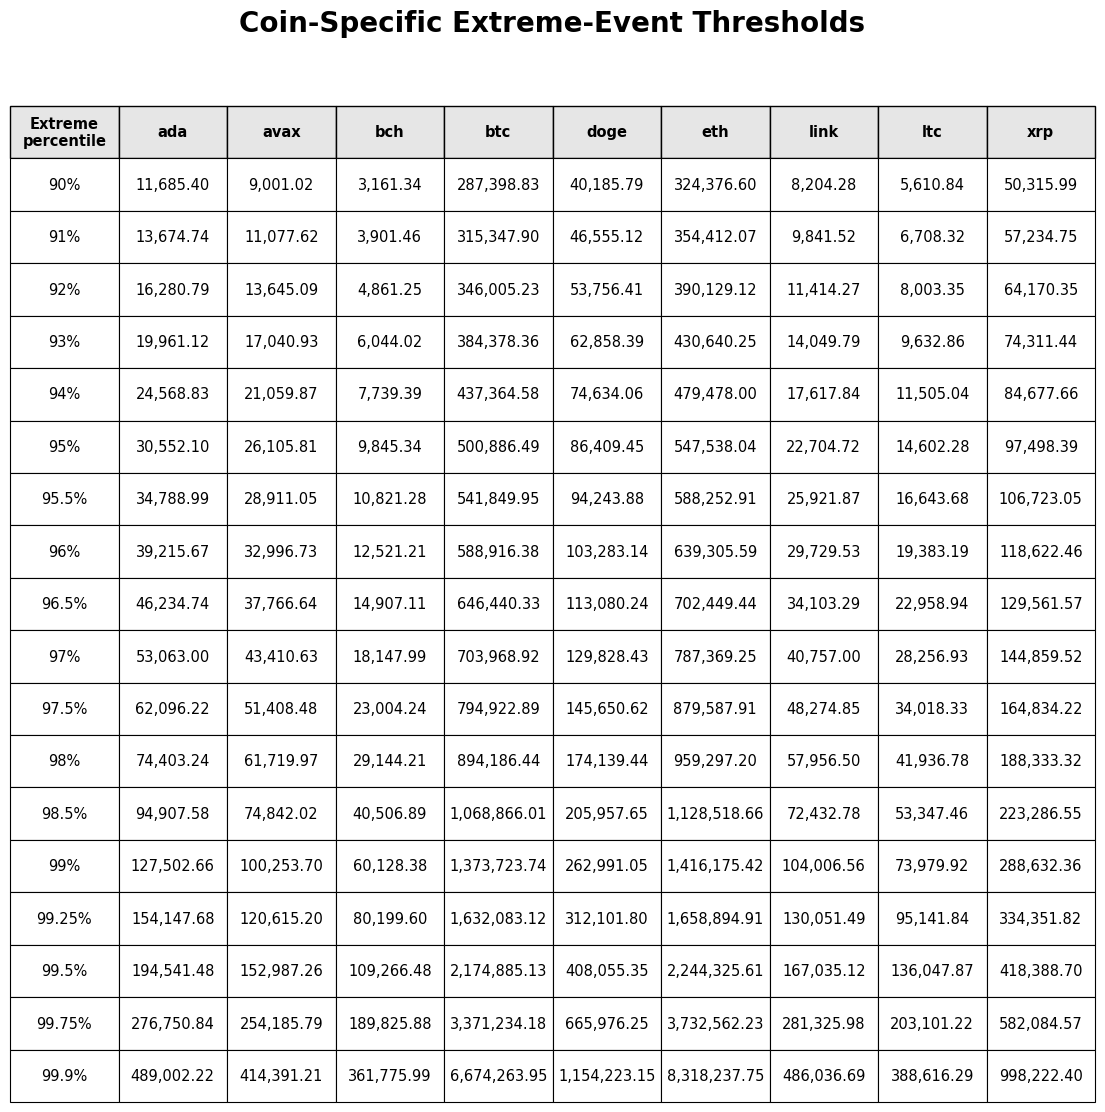

Macro-average performance across coins


,Extreme percentile,Model,Test PR-AUC,PR-AUC lift over random,Test precision,Test recall,Test F1,Number of test extremes,True positives,False positives,False negatives,True negatives,Coins with defined PR-AUC
0,90.00000,LSTM,0.14885,2.63685,0.20988,0.17872,0.18615,2584,497,1741,2087,40289,9
1,90.00000,Naive Baseline,0.13872,2.45640,0.16553,0.29373,0.20773,2584,819,3728,1765,38302,9
2,90.00000,Tweedie Regression,0.11811,2.07110,0.15985,0.18464,0.16015,2584,519,2703,2065,39327,9
3,90.00000,XGBoost,0.16292,2.94958,0.23302,0.21735,0.21253,2584,613,1997,1971,40033,9
4,91.00000,LSTM,0.13856,2.75918,0.19102,0.17247,0.17288,2306,445,1679,1861,40629,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,99.75000,XGBoost,0.06345,100.16986,0.06910,0.19266,0.02275,136,12,9448,124,35030,7
68,99.90000,LSTM,0.05952,188.08745,0.00410,0.11728,0.00555,55,5,897,50,43662,6
69,99.90000,Naive Baseline,0.01393,18.61283,0.00817,0.14712,0.01463,55,15,682,40,43877,6
70,99.90000,Tweedie Regression,0.01598,41.32609,0.00226,0.12963,0.00413,55,7,1753,48,42806,6


CPU times: total: 18min 7s
Wall time: 18min 10s


In [8]:
%%time

from sklearn.metrics import (average_precision_score,precision_score,recall_score,f1_score,confusion_matrix)

# ============================================================
# 1. Register all model predictions
# ============================================================

model_outputs = {"Naive Baseline": {"val_pred": np.asarray(naive_val_pred,dtype=np.float64).reshape(-1),
                                    "test_pred": np.asarray(naive_test_pred,dtype=np.float64).reshape(-1)},

                 "Tweedie Regression": {"val_pred": np.asarray(tweedie_val_pred,dtype=np.float64).reshape(-1),
                                        "test_pred": np.asarray(tweedie_test_pred,dtype=np.float64).reshape(-1)},
             
                 "LSTM": {"val_pred": np.asarray(lstm_val_pred,dtype=np.float64).reshape(-1),
                          "test_pred": np.asarray(lstm_test_pred,dtype=np.float64).reshape(-1)},
             
                 "XGBoost": {"val_pred": np.asarray(xgb_val_pred,dtype=np.float64).reshape(-1),
                             "test_pred": np.asarray(xgb_test_pred,dtype=np.float64).reshape(-1)}}

# ============================================================
# 2. Clean predictions
# ============================================================

for model_name, outputs in model_outputs.items():

    outputs["val_pred"] = np.clip(outputs["val_pred"],0,None)
    outputs["test_pred"] = np.clip(outputs["test_pred"],0,None)


# ============================================================
# 3. Coin-specific event definitions
# ============================================================

EXTREME_PERCENTILES = [90.0,91.0,92.0,93.0,94.0,95.0,95.5,96.0,96.5,97.0,97.5,98.0,98.5,99.0,99.25,99.5,99.75,99.9]

# These arrays preserve the exact endpoint ordering used by y_train, y_val, y_test
train_coins = (model_df.loc[train_idx, "coin"].astype(str).to_numpy())
val_coins = (model_df.loc[val_idx, "coin"].astype(str).to_numpy())
test_coins = (model_df.loc[test_idx, "coin"].astype(str).to_numpy())

for split_name, coins, target in [("training", train_coins, y_train),("validation", val_coins, y_val),("test", test_coins, y_test)]:
    coin_categories = sorted(np.unique(train_coins))

for split_name, coins in [("validation", val_coins),("test", test_coins)]:
    unseen_coins = (set(np.unique(coins)) - set(coin_categories))

# ============================================================
# 4. Evaluation Functions
# ============================================================

# Select a predicted-volume cutoff using validation F1
def select_validation_f1_threshold(actual_extreme,predicted_volume,number_of_candidates=1000):

    actual_extreme = np.asarray(actual_extreme,dtype=np.int8).reshape(-1)
    predicted_volume = np.asarray(predicted_volume,dtype=np.float64).reshape(-1)

    # Predict no extremes where validation had none for the given percentile
    if actual_extreme.sum() == 0:
        return (float(np.nextafter(predicted_volume.max(),np.inf)),0.0)

    candidate_thresholds = np.unique(np.quantile(predicted_volume,np.linspace(0,1,number_of_candidates)))

    best_threshold = float(candidate_thresholds[0])
    best_f1 = -np.inf

    for threshold in candidate_thresholds:

        predicted_extreme = (predicted_volume >= threshold).astype("int8")
        current_f1 = f1_score(actual_extreme,predicted_extreme,zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = float(threshold)

    return (best_threshold,float(best_f1))

def safe_pr_auc(actual_extreme,predicted_volume):
    """
    Return PR-AUC only when both test classes are present
    """

    actual_extreme = np.asarray(actual_extreme,dtype=np.int8).reshape(-1)
    predicted_volume = np.asarray(predicted_volume,dtype=np.float64).reshape(-1)

    if np.unique(actual_extreme).size < 2:
        return np.nan

    return float(average_precision_score(actual_extreme,predicted_volume))

# ============================================================
# 5. Training-derived actual-volume thresholds by coin
# ============================================================

training_targets_by_coin = pd.DataFrame({"Coin": train_coins,"Actual volume": y_train})

coin_threshold_rows = []
for extreme_percentile in EXTREME_PERCENTILES:
    current_thresholds = (training_targets_by_coin.groupby("Coin",sort=True)["Actual volume"].quantile(extreme_percentile / 100.0))
    
    for coin, threshold in current_thresholds.items():
        coin_threshold_rows.append({"Coin": coin,"Extreme percentile":extreme_percentile,"Actual volume threshold":float(threshold)})

coin_specific_thresholds = pd.DataFrame(coin_threshold_rows)

# ============================================================
# 6. Evaluate every model, coin and percentile
# ============================================================

coin_result_rows = []
observation_result_frames = []

for extreme_percentile in EXTREME_PERCENTILES:

    threshold_map = (coin_specific_thresholds.loc[coin_specific_thresholds["Extreme percentile"].eq(extreme_percentile)].
                     set_index("Coin")["Actual volume threshold"].to_dict())

    train_actual_thresholds = pd.Series(train_coins).map(threshold_map).to_numpy(dtype=np.float64)
    val_actual_thresholds = pd.Series(val_coins).map(threshold_map).to_numpy(dtype=np.float64)
    test_actual_thresholds = pd.Series(test_coins).map(threshold_map).to_numpy(dtype=np.float64)

    y_train_extreme_current = (y_train >= train_actual_thresholds).astype("int8")
    y_val_extreme_current = (y_val >= val_actual_thresholds).astype("int8")
    y_test_extreme_current = (y_test >= test_actual_thresholds).astype("int8")

    for model_name, outputs in model_outputs.items():

        validation_score = outputs["val_pred"]
        test_score = outputs["test_pred"]
        model_test_predicted_extreme = np.zeros(len(y_test),dtype=np.int8)

        for coin in coin_categories:

            train_mask = (train_coins == coin)
            validation_mask = (val_coins == coin)
            test_mask = (test_coins == coin)

            (predicted_volume_threshold,validation_f1) = select_validation_f1_threshold(
                actual_extreme=(y_val_extreme_current[validation_mask]),
                predicted_volume=(validation_score[validation_mask]),
                number_of_candidates=1000)

            coin_test_predicted_extreme = (test_score[test_mask] >= predicted_volume_threshold).astype("int8")

            model_test_predicted_extreme[test_mask] = coin_test_predicted_extreme

            coin_y_train = (y_train_extreme_current[train_mask])
            coin_y_val = (y_val_extreme_current[validation_mask])
            coin_y_test = (y_test_extreme_current[test_mask])
            coin_test_score = (test_score[test_mask])

            test_pr_auc = safe_pr_auc(coin_y_test,coin_test_score)
            test_precision = precision_score(coin_y_test,coin_test_predicted_extreme,zero_division=0)
            test_recall = recall_score(coin_y_test,coin_test_predicted_extreme,zero_division=0)
            test_f1 = f1_score(coin_y_test,coin_test_predicted_extreme,zero_division=0)

            tn, fp, fn, tp = confusion_matrix(coin_y_test,coin_test_predicted_extreme,labels=[0, 1]).ravel()

            train_prevalence = float(coin_y_train.mean())
            validation_prevalence = float(coin_y_val.mean())
            test_prevalence = float(coin_y_test.mean())

            pr_auc_lift = (test_pr_auc / test_prevalence 
                           if (np.isfinite(test_pr_auc) and test_prevalence > 0) else np.nan)

            coin_result_rows.append({
                "Coin": coin,
                "Model": model_name,
                "Extreme percentile": extreme_percentile,
                "Actual volume threshold": float(threshold_map[coin]),
                "Train prevalence": train_prevalence,
                "Validation prevalence": validation_prevalence,
                "Test prevalence": test_prevalence,
                "Number of test extremes": int(coin_y_test.sum()),
                "Predicted-volume threshold": predicted_volume_threshold,
                "Validation F1": validation_f1,
                "Test PR-AUC": test_pr_auc,
                "PR-AUC lift over random": pr_auc_lift,
                "Test precision": test_precision,
                "Test recall": test_recall,
                "Test F1": test_f1,
                "True positives": int(tp),
                "False positives": int(fp),
                "False negatives": int(fn),
                "True negatives": int(tn)})

        observation_result_frames.append(
            pd.DataFrame({"Coin": test_coins,
                          "Extreme percentile": extreme_percentile,
                          "Model": model_name,
                          "Actual volume": y_test,
                          "Predicted volume": test_score,
                          "Actual volume threshold": test_actual_thresholds,
                          "Actual extreme": y_test_extreme_current,
                          "Predicted extreme": model_test_predicted_extreme}))


# ============================================================
# 7. Build intermediate and observation-level results
# ============================================================

coin_specific_extreme_results = (pd.DataFrame(coin_result_rows).sort_values(["Extreme percentile","Coin","Test PR-AUC"],ascending=[True,True,False]).reset_index(drop=True))

coin_specific_test_predictions = (pd.concat(observation_result_frames,ignore_index=True))

# threshold table
threshold_display_table = (coin_specific_thresholds.pivot(index="Extreme percentile",columns="Coin",values="Actual volume threshold").
                           sort_index().reindex(columns=coin_categories))

threshold_table_values = []

for percentile, row in (threshold_display_table.iterrows()):
    formatted_row = [f"{percentile:g}%"]

    for coin in threshold_display_table.columns:
        value = row[coin]
        formatted_row.append( "—" if pd.isna(value) else f"{value:,.2f}")

    threshold_table_values.append(formatted_row)

threshold_column_labels = ["Extreme\npercentile",*threshold_display_table.columns]
threshold_figure_width = max(14,1.35 * len(threshold_column_labels))
threshold_figure_height = ( 2.6 + 0.62 * len(threshold_table_values))

fig, threshold_ax = plt.subplots(figsize=(threshold_figure_width,threshold_figure_height))

threshold_ax.axis("off")
threshold_ax.set_title("Coin-Specific Extreme-Event Thresholds",fontsize=20,fontweight="bold",pad=8)

threshold_table = threshold_ax.table(cellText=threshold_table_values,colLabels=threshold_column_labels,cellLoc="center",colLoc="center",bbox=[0, 0, 1, 0.94])
threshold_table.auto_set_font_size(False)
threshold_table.set_fontsize(10.5)
threshold_table.scale(1,1.7)

number_of_threshold_columns = len(threshold_column_labels)
equal_threshold_column_width = (1 / number_of_threshold_columns)

for (row_number,column_number), cell in threshold_table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)
    cell.set_width(equal_threshold_column_width)

    # All data rows remain white: no alternating shading.
    cell.set_facecolor("white")

    if row_number == 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold",fontsize=10.5)
        cell.set_linewidth(1.0)

plt.show()

# ============================================================
# 8. Macro-average results across coins
# ============================================================

extreme_sensitivity_results = (coin_specific_extreme_results.groupby(["Extreme percentile","Model"],as_index=False)
    .agg(**{"Test PR-AUC": ("Test PR-AUC","mean"),
            "PR-AUC lift over random": ("PR-AUC lift over random","mean"),
            "Test precision": ("Test precision","mean"),
            "Test recall": ("Test recall","mean"),
            "Test F1": ("Test F1","mean"),
            "Number of test extremes": ("Number of test extremes","sum"),
            "True positives": ("True positives","sum"),
            "False positives": ("False positives","sum"),
            "False negatives": ("False negatives","sum"),
            "True negatives": ("True negatives","sum"),
            "Coins with defined PR-AUC": ("Test PR-AUC","count")}))

print("Macro-average performance across coins")

display(extreme_sensitivity_results)

pr_auc_by_percentile = (extreme_sensitivity_results.pivot(index="Extreme percentile",columns="Model",values="Test PR-AUC"))
pr_auc_lift_by_percentile = (extreme_sensitivity_results.pivot(index="Extreme percentile",columns="Model",values="PR-AUC lift over random"))
f1_by_percentile = (extreme_sensitivity_results.pivot(index="Extreme percentile",columns="Model",values="Test F1"))
precision_by_percentile = (extreme_sensitivity_results.pivot(index="Extreme percentile",columns="Model",values="Test precision"))
recall_by_percentile = (extreme_sensitivity_results.pivot(index="Extreme percentile",columns="Model",values="Test recall"))


### Export Results

In [9]:


SCRIPT_NAME = "Machine Learning Models-Without_Order_Book"  

test_cumulative_export = test_cumulative_results.reset_index().rename(columns={"index": "Model"})
test_cumulative_export.insert(0, "Script name", SCRIPT_NAME)

extreme_sensitivity_export = extreme_sensitivity_results.copy()
extreme_sensitivity_export.insert(0, "Script name", SCRIPT_NAME)

# Export to Excel files
test_cumulative_export.to_excel(f"outputs/test_cumulative_results_{SCRIPT_NAME}.xlsx",index=False)
extreme_sensitivity_export.to_excel(f"outputs/extreme_sensitivity_results_{SCRIPT_NAME}.xlsx",index=False)

print(f"Exported: test_cumulative_export{SCRIPT_NAME}.xlsx")
print(f"Exported: extreme_sensitivity_results_{SCRIPT_NAME}.xlsx")

Exported: test_cumulative_exportMachine Learning Models-Without_Order_Book.xlsx
Exported: extreme_sensitivity_results_Machine Learning Models-Without_Order_Book.xlsx
